<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/SP/SP_image_intensity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab4 Spectroscopy experiment. Image processing

Yulia Preezant and Evgeny Kolonsky, 2025

v.0.1.4

# Helium

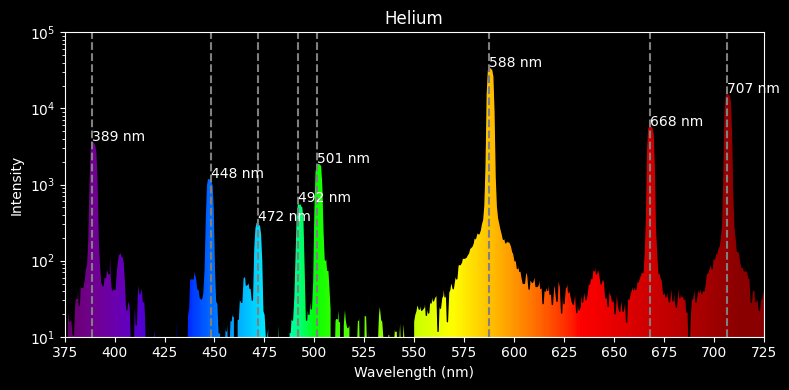

In [40]:
# prompt: read png, replace all pixel with intensity

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests

path = 'https://github.com/evgeny-kolonsky/Lab4/blob/main/SP/'


def get_and_show(file, show=True):
  url = f'{path}{file}/?raw=true'

  # Load the image
  img = Image.open(requests.get(url, stream=True).raw)
  # crop
  imageBox = img.getbbox()
  cropped = img.crop(imageBox)

  # Convert to grayscale
  img_gray = cropped.convert('L')
  # Convert image to a numpy array
  img_array = np.array(img_gray)
  # Sum over y-axis
  v = np.sum(img_array, axis=0) + 1


  # show
  if show:
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.imshow(img, origin='lower')
    ax2.plot(v,'-', color='gray', alpha=0.5)
    ax2.set_ylabel('Intensity', color='b')
    ax2.set_yscale('log')
    ax1.set_ylabel('')

  return v, img




# Blue lines

array([25570, 25571, 25574, ..., 12117, 12105, 12123], dtype=uint64)

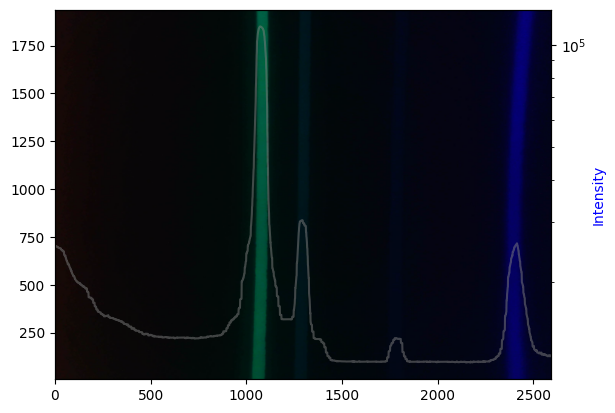

In [33]:
file = '0002.png'
get_and_show(file)

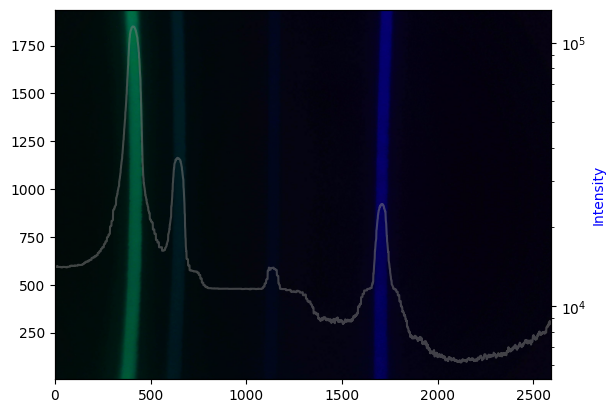

In [13]:
file = '0004.png'
get_and_show(file)

*Suggestion:*

Strong green line  501 nm, next to her weak green line 492 nm, next blue line 448 nm. blue line 472 nm is hardly seen


# Red lines

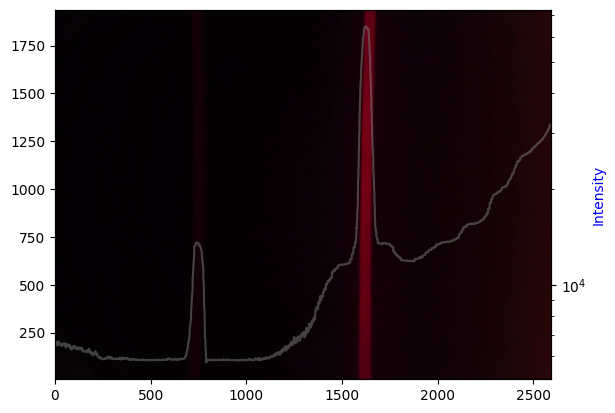

In [14]:
file = '0006.png'
get_and_show(file)

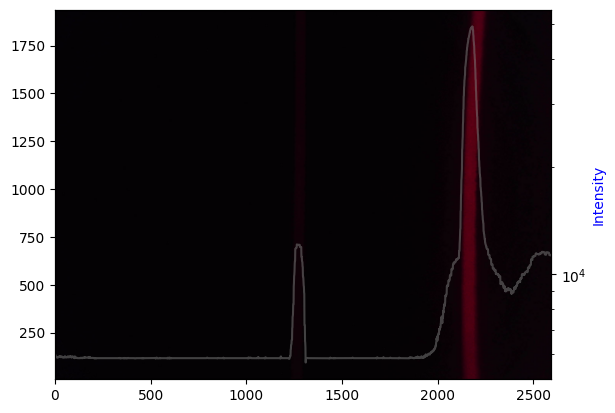

In [15]:
file = '0008.png'
get_and_show(file)

*Suggestion:*

Strong red line 668 nm, weak red line 707 nm

# White light

Using variac descrease white lamp power and see how intesity profile changes.

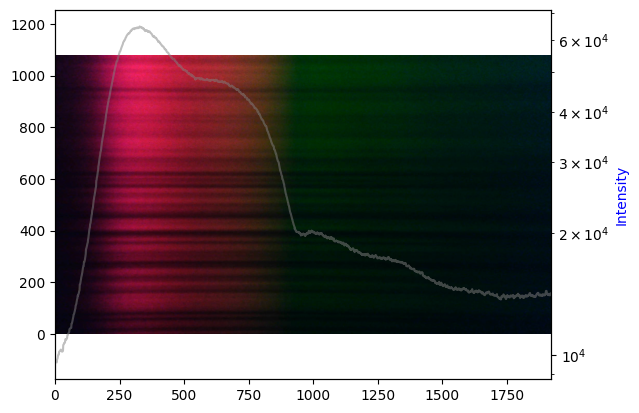

In [20]:
file = 'white0.png'
get_and_show(file)

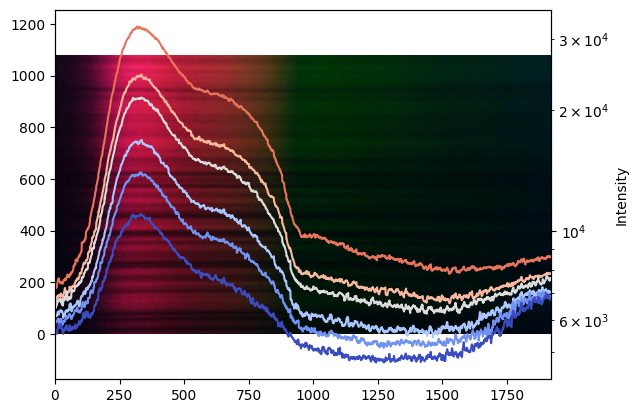

In [46]:
colors = plt.cm.coolwarm(np.linspace(1, 0, 7))
for n in range(7):
  file = f'w{n}.png'
  v, img = get_and_show(file, show=False)
  plt.plot(v, color=colors[n], label=f'{n=}')
  if n == 0:
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    ax1.imshow(img, origin='lower')
    ax2.set_ylabel('Intensity')
    ax2.set_yscale('log')
    ax1.set_ylabel('')

  plt.yscale('log')
